In [2]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
import os
print(os.getcwd())

C:\Users\attacker\Downloads\ransomware-detection-system-main\notebooks


In [4]:
df = pd.read_csv("../data/pe_features.csv")
df.head()

,sha256,file_name,num_sections,size_of_image,size_of_code,entry_point,num_imports,num_dlls,avg_entropy,max_entropy,min_entropy,label
0,e73f63dd1d250708691539a00fb39d8d8d0d21b5c0d5bb...,AgentService.exe,6,1236992,835584,779312,261,11,5.002943,6.333828,2.984349,0
1,ba1e0a8f8f477ee434c1b44cb682fbd2250cacb7f4cd2e...,appidpolicyconverter.exe,7,180224,97280,89696,141,30,4.149537,6.169772,0.614527,0
2,6a5e560adcb4ecbf3dc948516a96cff2d9f040ec114e9c...,ApplySettingsTemplateCatalog.exe,6,1179648,808448,756384,237,8,4.950145,6.329723,2.677461,0
3,076f2d6cf180c6056ff4b7018a5725327eea3cb4a309dc...,ApplyTrustOffline.exe,7,1216512,525312,19888,348,55,3.958585,6.631824,1.102010,0
4,99a11a729a9eddc0ced9ace690c1fc2b7e1c297ce2518d...,ApproveChildRequest.exe,6,253952,88576,82544,157,23,5.389040,7.411663,4.360826,0


In [5]:
df.shape

(500, 12)

In [6]:
df["label"].value_counts()

label
0    250
1    250
Name: count, dtype: int64

In [7]:
print(df.columns)

Index(['sha256', 'file_name', 'num_sections', 'size_of_image', 'size_of_code',
       'entry_point', 'num_imports', 'num_dlls', 'avg_entropy', 'max_entropy',
       'min_entropy', 'label'],
      dtype='str')


In [8]:
df = df.drop(["sha256","file_name"], axis=1)
df.head()

,num_sections,size_of_image,size_of_code,entry_point,num_imports,num_dlls,avg_entropy,max_entropy,min_entropy,label
0,6,1236992,835584,779312,261,11,5.002943,6.333828,2.984349,0
1,7,180224,97280,89696,141,30,4.149537,6.169772,0.614527,0
2,6,1179648,808448,756384,237,8,4.950145,6.329723,2.677461,0
3,7,1216512,525312,19888,348,55,3.958585,6.631824,1.102010,0
4,6,253952,88576,82544,157,23,5.389040,7.411663,4.360826,0


In [9]:
X = df.drop("label", axis=1)
y = df["label"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [11]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
pred = model.predict(X_test)

In [13]:
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.96      0.93      0.95        46
           1       0.95      0.96      0.95        54

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100



In [14]:
!py -m pip install seaborn

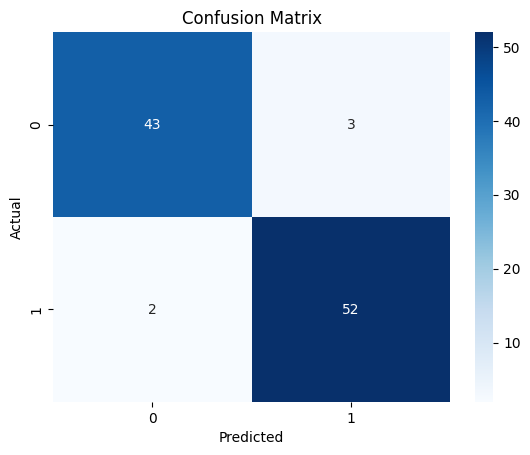

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt 

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix") 

plt.show()

In [16]:
#Compare between models 

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

In [17]:
models = { 
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=3000)
}

In [18]:


results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc

print(results)

{'Random Forest': 0.96, 'Decision Tree': 0.92, 'KNN': 0.85, 'Logistic Regression': 0.88}


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}

for name, model in models.items():
    
    if name in ["LogisticRegression", "SVM", "KNN"]:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    results[name] = accuracy_score(y_test, pred)

print(results)

{'Random Forest': 0.95, 'Decision Tree': 0.91, 'KNN': 0.92, 'Logistic Regression': 0.88}


In [20]:
for model_name, score in results.items():
    print(model_name, "Accuracy:", score)

Random Forest Accuracy: 0.95
Decision Tree Accuracy: 0.91
KNN Accuracy: 0.92
Logistic Regression Accuracy: 0.88


In [21]:
import pandas as pd 

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df

,Model,Accuracy
0,Random Forest,0.95
1,Decision Tree,0.91
2,KNN,0.92
3,Logistic Regression,0.88


In [22]:
#---------------------------------------------------------------#

In [23]:
import joblib
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(n_estimators=200, random_state=42)
final_model.fit(X_train, y_train)

joblib.dump(final_model, "model.pkl")
print("Model saved successfully.")

Model saved successfully.


In [24]:
import pefile
import numpy as np
import math
from collections import Counter

def calculate_entropy(data):
    if not data:
        return 0.0
    
    counter = Counter(data)
    length = len(data)
    
    entropy = 0
    for count in counter.values():
        p = count / length
        entropy -= p * math.log2(p)
    
    return entropy


def extract_features(file_path):
    try:
        pe = pefile.PE(file_path)

        num_sections  = pe.FILE_HEADER.NumberOfSections
        size_of_image = pe.OPTIONAL_HEADER.SizeOfImage
        size_of_code  = pe.OPTIONAL_HEADER.SizeOfCode
        entry_point   = pe.OPTIONAL_HEADER.AddressOfEntryPoint

        num_imports = 0
        num_dlls    = 0

        if hasattr(pe, 'DIRECTORY_ENTRY_IMPORT'):
            num_dlls = len(pe.DIRECTORY_ENTRY_IMPORT)
            for entry in pe.DIRECTORY_ENTRY_IMPORT:
                num_imports += len(entry.imports)

        entropies   = [calculate_entropy(s.get_data()) for s in pe.sections]
        avg_entropy = np.mean(entropies) if entropies else 0.0
        max_entropy = np.max(entropies)  if entropies else 0.0
        min_entropy = np.min(entropies)  if entropies else 0.0

        return np.array([
            num_sections,
            size_of_image,
            size_of_code,
            entry_point,
            num_imports,
            num_dlls,
            avg_entropy,
            max_entropy,
            min_entropy
        ])

    except Exception as e:
        print("Error:", e)
        return None

In [25]:
#Predection

import joblib
import numpy as np

def predict(file_path):
    model = joblib.load("model.pkl")

    features = extract_features(file_path)

    if features is None:
        return "Invalid PE file"

    features = features.reshape(1, -1)

    prediction = model.predict(features)[0]
    prob       = model.predict_proba(features)[0]
    confidence = max(prob) * 100

    if prediction == 1:
        return f"RANSOMWARE ({confidence:.2f}%)"
    else:
        return f"BENIGN ({confidence:.2f}%)"

In [26]:
feature_names = [
    "num_sections",
    "size_of_image",
    "size_of_code",
    "entry_point",
    "num_imports",
    "num_dlls",
    "avg_entropy",
    "max_entropy",
    "min_entropy"
]

In [27]:
import pandas as pd

file = "bdesvc.dll"

# استخراج الـ features
features = extract_features(file)

# تحويلها لـ DataFrame
df = pd.DataFrame([features], columns=feature_names)

# prediction
prediction = model.predict(df)[0]

# تحويل النتيجة لكلام مفهوم
label_map = {0: "Benign", 1: "Ransomware"}

print("Prediction:", label_map[prediction])

# حساب نسبة الثقة
proba = model.predict_proba(df)[0]

benign_prob = proba[0] * 100
ransom_prob = proba[1] * 100

print(f"Benign Probability: {benign_prob:.2f}%")
print(f"Ransomware Probability: {ransom_prob:.2f}%")

Prediction: Benign
Benign Probability: 99.98%
Ransomware Probability: 0.02%


In [32]:
model = joblib.load("model.pkl")

In [33]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.95
Precision: 0.9454545454545454
Recall: 0.9629629629629629
F1 Score: 0.9541284403669725


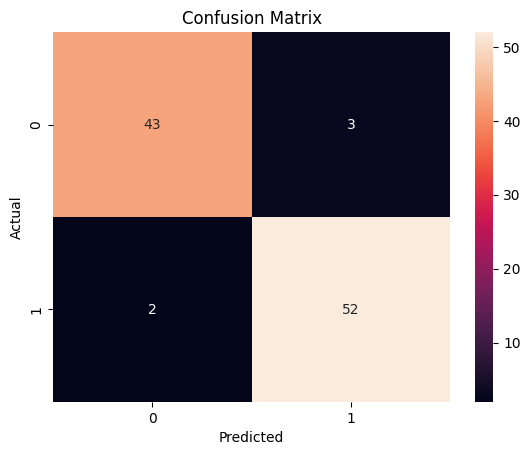

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

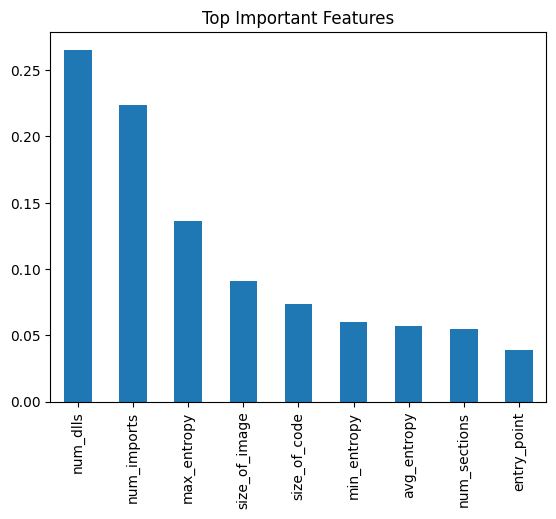

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_
feat = pd.Series(importance, index=X_test.columns)

feat.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Important Features")
plt.show()